# 2. Transfer learning: EfficientNet-B0

Тот же split, что в `01_scratch_cnn.ipynb`, чтобы сравнивать честно.

Две фазы:
1. linear probe — замороженный backbone, учим только classifier
2. fine-tune последних блоков с маленьким lr

ImageNet-нормы и 224px, иначе претрейн почти бесполезен.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.auto import tqdm

import petsdata as P

sns.set_theme(style="whitegrid")
P.set_seed(P.SEED)
device = P.get_device()
P.CKPT_DIR.mkdir(exist_ok=True)

train_df, val_df, test_df, breed2id = P.ensure_splits()
id2breed = {i: b for b, i in breed2id.items()}
N = len(breed2id)
print(len(train_df), len(val_df), len(test_df), "classes", N, "device", device)


2247 482 482 classes 37 device mps


/Users/mnfom/Projects/cnn-Makarena-211/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SIZE = 224
BATCH = 32 if device.type != "cpu" else 8
tfms = P.make_tfms(SIZE, imagenet=True, erase=False)
train_loader, val_loader, test_loader = P.make_loaders(
    train_df, val_df, test_df, tfms, batch=BATCH
)


In [3]:
def build_effnet(n_classes, pretrained=True):
    w = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    m = efficientnet_b0(weights=w)
    in_f = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_f, n_classes)
    return m


def set_trainable(model, mode: str):
    # mode: probe | last | all
    for p in model.parameters():
        p.requires_grad = False
    if mode == "probe":
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif mode == "last":
        for p in model.features[-2:].parameters():
            p.requires_grad = True
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif mode == "all":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError(mode)
    return [p for p in model.parameters() if p.requires_grad]


@torch.no_grad()
def eval_cls(model, loader):
    model.eval()
    crit = nn.CrossEntropyLoss()
    n = loss_sum = acc1 = acc3 = 0.0
    ys, ps = [], []
    for batch in loader:
        x = batch["image"].to(device)
        y = batch["breed"].to(device)
        logits = model(x)
        loss = crit(logits, y)
        bs = x.size(0)
        n += bs
        loss_sum += loss.item() * bs
        pred = logits.topk(3, dim=1).indices
        acc1 += pred[:, :1].eq(y[:, None]).any(1).float().sum().item()
        acc3 += pred.eq(y[:, None]).any(1).float().sum().item()
        ys.append(y.cpu())
        ps.append(logits.softmax(1).cpu())
    return {
        "loss": loss_sum / n,
        "top1": acc1 / n,
        "top3": acc3 / n,
        "y": torch.cat(ys).numpy(),
        "prob": torch.cat(ps).numpy(),
    }


def fit(model, loader_tr, loader_va, epochs, lr, wd, tag):
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(epochs, 1))
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    best = -1.0
    best_state = None
    log = []
    for ep in range(1, epochs + 1):
        model.train()
        n = loss_sum = 0.0
        for batch in tqdm(loader_tr, leave=False, desc=f"{tag} {ep}"):
            x = batch["image"].to(device)
            y = batch["breed"].to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(params, 5.0)
            opt.step()
            n += x.size(0)
            loss_sum += loss.item() * x.size(0)
        sched.step()
        va = eval_cls(model, loader_va)
        log.append(
            {
                "phase": tag,
                "epoch": ep,
                "train_loss": loss_sum / n,
                "val_top1": va["top1"],
                "val_top3": va["top3"],
            }
        )
        mark = ""
        if va["top1"] > best:
            best = va["top1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            mark = "*"
        print(
            f"[{tag}] {ep:02d} train {loss_sum/n:.3f}  val top1 {va['top1']:.3f} top3 {va['top3']:.3f} {mark}"
        )
    model.load_state_dict(best_state)
    return pd.DataFrame(log), best


### Фаза A — linear probe


In [4]:
model = build_effnet(N, pretrained=True).to(device)
set_trainable(model, "probe")
print("trainable", sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6, "M")
log_a, best_a = fit(model, train_loader, val_loader, epochs=6, lr=1e-3, wd=1e-3, tag="probe")
print("best probe val", best_a)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/mnfom/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 23.7MB/s]


trainable 0.047397 M


[probe] 01 train 3.067  val top1 0.529 top3 0.780 *


[probe] 02 train 2.275  val top1 0.618 top3 0.836 *


[probe] 03 train 1.929  val top1 0.685 top3 0.861 *


[probe] 04 train 1.803  val top1 0.693 top3 0.865 *


[probe] 05 train 1.724  val top1 0.701 top3 0.876 *


[probe] 06 train 1.690  val top1 0.699 top3 0.878 
best probe val 0.7012448132780082


### Фаза B — размораживаем последние блоки


trainable 1.176789 M


[finetune] 01 train 1.545  val top1 0.766 top3 0.915 *


[finetune] 02 train 1.354  val top1 0.780 top3 0.925 *


[finetune] 03 train 1.257  val top1 0.770 top3 0.929 


[finetune] 04 train 1.182  val top1 0.793 top3 0.944 *


...

[finetune] 06 train 1.093  val top1 0.795 top3 0.946 *


[finetune] 07 train 1.065  val top1 0.797 top3 0.944 *


[finetune] 08 train 1.053  val top1 0.801 top3 0.946 *


[finetune] 09 train 1.042  val top1 0.799 top3 0.948 


[finetune] 10 train 1.031  val top1 0.797 top3 0.942 
best ft val 0.8008298755186722


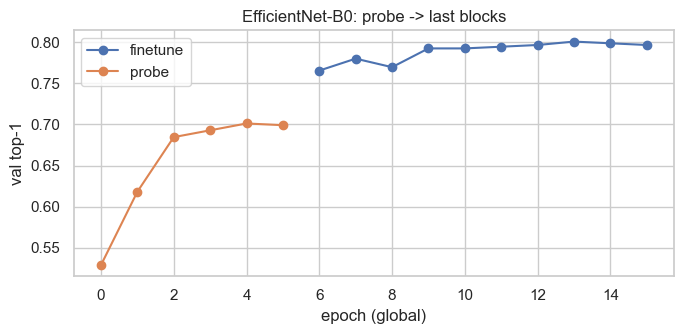

In [5]:
set_trainable(model, "last")
print("trainable", sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6, "M")
log_b, best_b = fit(model, train_loader, val_loader, epochs=10, lr=3e-4, wd=1e-4, tag="finetune")
print("best ft val", best_b)

ckpt = P.CKPT_DIR / "effnet_b0.pt"
torch.save({"state": model.state_dict(), "breed2id": breed2id, "val_top1": best_b}, ckpt)

logs = pd.concat([log_a, log_b], ignore_index=True)
logs["step"] = np.arange(len(logs))
fig, ax = plt.subplots(figsize=(7, 3.5))
for phase, g in logs.groupby("phase"):
    ax.plot(g.step, g.val_top1, marker="o", label=phase)
ax.set_ylabel("val top-1")
ax.set_xlabel("epoch (global)")
ax.legend()
ax.set_title("EfficientNet-B0: probe -> last blocks")
plt.tight_layout()
plt.show()


test top-1 0.8154 | top-3 0.9544
species from breed: 0.9896265560165975
                            precision    recall  f1-score   support

                Abyssinian       0.91      0.71      0.80        14
                    Bengal       0.60      0.55      0.57        11
                    Birman       0.70      1.00      0.82        14
                    Bombay       0.79      0.85      0.81        13
         British Shorthair       0.74      0.93      0.82        15
              Egyptian Mau       0.58      0.64      0.61        11
                Maine Coon       0.76      0.93      0.84        14
                   Persian       1.00      0.86      0.92        14
                   Ragdoll       0.91      0.67      0.77        15
              Russian Blue       0.91      0.67      0.77        15
                   Siamese       0.93      0.87      0.90        15
                    Sphynx       0.94      1.00      0.97        15
          american bulldog       1.00      

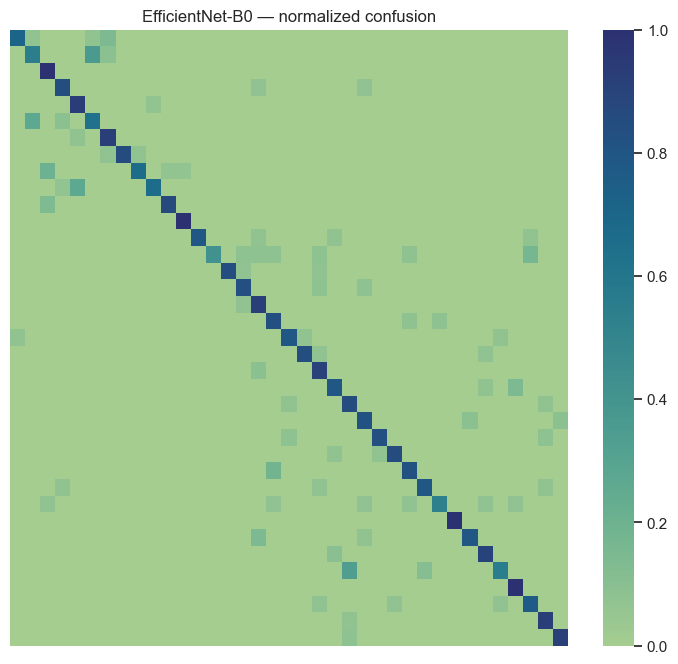

In [6]:
te = eval_cls(model, test_loader)
print(f"test top-1 {te['top1']:.4f} | top-3 {te['top3']:.4f}")

# binary cat/dog через маппинг породы
full = pd.concat([train_df, val_df, test_df], ignore_index=True)
b2s = full.groupby("breed_id")["species_id"].agg(lambda s: int(s.mode().iloc[0])).to_dict()
y_hat = te["prob"].argmax(1)
sp_hat = np.array([b2s[int(i)] for i in y_hat])
print("species from breed:", (sp_hat == test_df["species_id"].values).mean())

names = [P.pretty_label(id2breed[i]) for i in range(N)]
print(classification_report(te["y"], y_hat, target_names=names, zero_division=0))

cm = confusion_matrix(te["y"], y_hat, labels=np.arange(N))
cm_n = cm / np.clip(cm.sum(1, keepdims=True), 1, None)
plt.figure(figsize=(9, 8))
sns.heatmap(cm_n, cmap="crest", xticklabels=False, yticklabels=False, vmin=0, vmax=1)
plt.title("EfficientNet-B0 — normalized confusion")
plt.show()


Контроль без претрейна (короткий, чтобы увидеть, что ImageNet реально даёт буст, а не просто ёмкость сети).


In [7]:
scratch_eff = build_effnet(N, pretrained=False).to(device)
set_trainable(scratch_eff, "all")
_, best_scratch = fit(
    scratch_eff, train_loader, val_loader, epochs=4, lr=1e-3, wd=1e-4, tag="no-pretrain"
)
print("EfficientNet-B0 from scratch, 4 ep val top1:", best_scratch)
print("pretrained fine-tune val top1:", best_b)


[no-pretrain] 01 train 3.603  val top1 0.091 top3 0.193 *


[no-pretrain] 02 train 3.338  val top1 0.141 top3 0.303 *


[no-pretrain] 03 train 3.191  val top1 0.187 top3 0.382 *


[no-pretrain] 04 train 2.989  val top1 0.222 top3 0.467 *
EfficientNet-B0 from scratch, 4 ep val top1: 0.22199170124481327
pretrained fine-tune val top1: 0.8008298755186722
